In [1]:
import pandas as pd

df = pd.read_csv("../data/TSLA.csv")

In [2]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.2+ KB


,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


In [3]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
import matplotlib.pyplot as plt

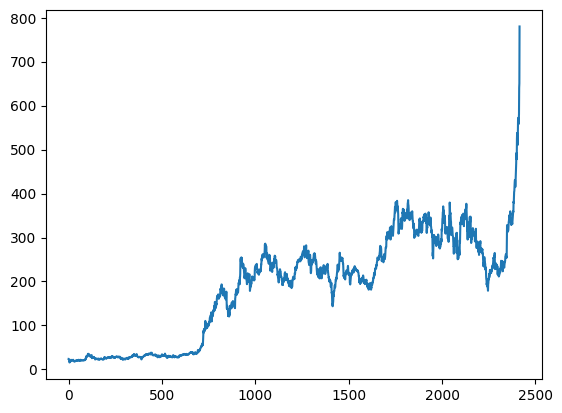

In [6]:
### Closing Price Trend

plt.plot(df['Close'])


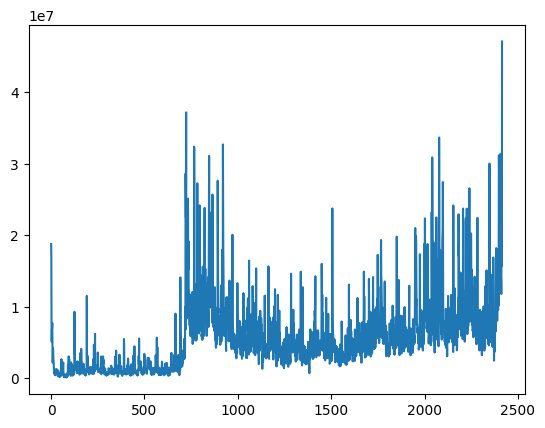

In [7]:
### Volume Trend

plt.plot(df['Volume'])


In [8]:
import seaborn as sns


<Axes: >

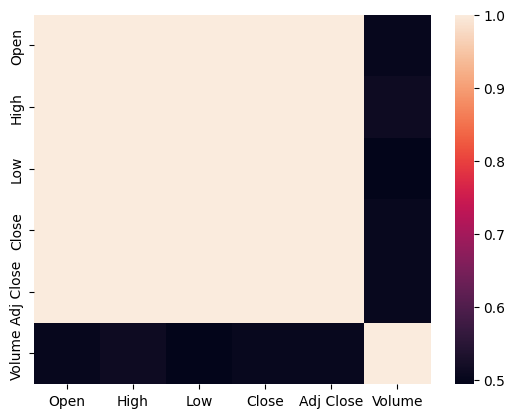

In [9]:
### Correlation Heatmap

sns.heatmap(df.corr(numeric_only=True))


In [10]:
### Feature Engineering

df['Date'] = pd.to_datetime(df['Date'])


In [11]:
df.set_index('Date', inplace=True)


In [12]:
data = df[['Close']]


In [13]:
### Scaling

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)


In [14]:
### Sequence Creation

window_size = 60


In [15]:
import numpy as np


In [16]:
X=[]
y=[]

for i in range(window_size,len(scaled_data)):

    X.append(scaled_data[i-window_size:i])

    y.append(scaled_data[i])

X=np.array(X)
y=np.array(y)


In [17]:
print(X.shape)


(2356, 60, 1)


In [ ]:
### Train Test Split

split = int(len(X) \* 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)


X_train Shape: (1884, 60, 1)
X_test Shape: (472, 60, 1)
y_train Shape: (1884, 1)
y_test Shape: (472, 1)


In [ ]:
### Model-1:- SimpleRNN:-

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout


In [ ]:
rnn_model = Sequential()

rnn_model.add(
SimpleRNN(
50,
return_sequences=True,
input_shape=(60,1)
)
)

rnn_model.add(Dropout(0.2))

rnn_model.add(SimpleRNN(50))

rnn_model.add(Dense(1))


c:\Users\arjya\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
rnn_model.compile(
optimizer='adam',
loss='mse'
)


In [ ]:
### Train:

history_rnn = rnn_model.fit(
X_train,
y_train,
epochs=20,
batch_size=32,
validation_split=0.2
)


Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0261 - val_loss: 0.0031
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0019 - val_loss: 0.0029
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0010 - val_loss: 0.0022
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 9.5827e-04 - val_loss: 6.0593e-04
Epoch 5/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 7.0514e-04 - val_loss: 0.0025
Epoch 6/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 6.3739e-04 - val_loss: 4.1690e-04
Epoch 7/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 6.0703e-04 - val_loss: 8.1124e-04
Epoch 8/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 4.6974e-04 - val_loss: 4.3531e-04
Epoch 9/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3.2572e-04 - val_loss: 5.4180e-04
Epoch 10/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3.4197e-04 - val_loss: 0.0014
Epoch 11/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 5.3200e-04 - val_loss: 3.3087e-04
Epoch 1

In [ ]:
### Save:

rnn_model.save("../models/best_rnn.keras")


In [ ]:
### Model-2:-STM:-

from tensorflow.keras.layers import LSTM


In [ ]:
lstm_model = Sequential()

lstm_model.add(
LSTM(
50,
return_sequences=True,
input_shape=(60,1)
)
)

lstm_model.add(Dropout(0.2))

lstm_model.add(LSTM(50))

lstm_model.add(Dense(1))


In [ ]:
### Compile:

lstm_model.compile(
optimizer='adam',
loss='mse'
)


In [ ]:
### Train:

history_lstm = lstm_model.fit(
X_train,
y_train,
epochs=20,
batch_size=32,
validation_split=0.2
)


Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 0.0121 - val_loss: 4.2862e-04
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 3.5571e-04 - val_loss: 4.0213e-04
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 2.4805e-04 - val_loss: 5.2200e-04
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 2.2662e-04 - val_loss: 7.7892e-04
Epoch 5/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 2.2949e-04 - val_loss: 6.9559e-04
Epoch 6/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 2.4908e-04 - val_loss: 6.6739e-04
Epoch 7/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 1.8257e-04 - val_loss: 5.9629e-04
Epoch 8/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 1.9162e-04 - val_loss: 4.6066e-04
Epoch 9/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 1.8295e-04 - val_loss: 4.9583e-04
Epoch 10/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 1.9168e-04 - val_loss: 3.8317e-04
Epoch 11/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 1.9381e-04 - 

In [ ]:
### Save:

lstm_model.save("../models/best_lstm.keras")


In [ ]:
### Model-3:- GRU:-

from tensorflow.keras.layers import GRU


In [ ]:
gru_model = Sequential()

gru_model.add(
GRU(
50,
return_sequences=True,
input_shape=(60,1)
)
)

gru_model.add(Dropout(0.2))

gru_model.add(GRU(50))

gru_model.add(Dense(1))


In [ ]:
### Compile:

gru_model.compile(
optimizer='adam',
loss='mse'
)


In [ ]:
### Train:

history_gru = gru_model.fit(
X_train,
y_train,
epochs=20,
batch_size=32,
validation_split=0.2
)


Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - loss: 0.0107 - val_loss: 2.1097e-04
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 2.0276e-04 - val_loss: 1.9600e-04
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 1.9350e-04 - val_loss: 1.9095e-04
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 1.8688e-04 - val_loss: 2.0450e-04
Epoch 5/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 1.4523e-04 - val_loss: 1.8653e-04
Epoch 6/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 1.3872e-04 - val_loss: 1.8595e-04
Epoch 7/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 1.4585e-04 - val_loss: 1.9260e-04
Epoch 8/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 1.3573e-04 - val_loss: 1.7980e-04
Epoch 9/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 1.3717e-04 - val_loss: 1.7374e-04
Epoch 10/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 1.5183e-04 - val_loss: 1.9658e-04
Epoch 11/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 1.0995e-04 - 

In [ ]:
### Save:

gru_model.save(
"../models/best_gru.keras"
)


In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import numpy as np


In [ ]:
### SimpleRNN Evaluation

rnn_pred = rnn_model.predict(X_test)


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


In [ ]:
rnn_pred = scaler.inverse_transform(rnn_pred)

y_actual = scaler.inverse_transform(y_test)


In [ ]:
### Calculate Metrics:-

### MSE:-

mse_rnn = mean_squared_error(
y_actual,
rnn_pred
)


In [ ]:
### RMSE

rmse_rnn = np.sqrt(mse_rnn)


In [ ]:
### MAE

mae_rnn = mean_absolute_error(
y_actual,
rnn_pred
)


In [ ]:
### Print Results

print("SimpleRNN Results")
print("MSE :", mse_rnn)
print("RMSE :", rmse_rnn)
print("MAE :", mae_rnn)


SimpleRNN Results
MSE : 1105.1761192365773
RMSE : 33.244189255215375
MAE : 23.765661039267336


In [ ]:
### LSTM Evaluation:-

lstm_pred = lstm_model.predict(X_test)

lstm_pred = scaler.inverse_transform(lstm_pred)

mse_lstm = mean_squared_error(
y_actual,
lstm_pred
)

rmse_lstm = np.sqrt(mse_lstm)

mae_lstm = mean_absolute_error(
y_actual,
lstm_pred
)

print("LSTM Results")
print("MSE :", mse_lstm)
print("RMSE :", rmse_lstm)
print("MAE :", mae_lstm)


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
LSTM Results
MSE : 682.2498224351773
RMSE : 26.119912374186427
MAE : 16.93257547580939


In [ ]:
### GRU Evaluation

gru_pred = gru_model.predict(X_test)

gru_pred = scaler.inverse_transform(gru_pred)

mse_gru = mean_squared_error(
y_actual,
gru_pred
)

rmse_gru = np.sqrt(mse_gru)

mae_gru = mean_absolute_error(
y_actual,
gru_pred
)

print("GRU Results")
print("MSE :", mse_gru)
print("RMSE :", rmse_gru)
print("MAE :", mae_gru)


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
GRU Results
MSE : 393.3127779189876
RMSE : 19.832114812066504
MAE : 13.257341063598634


In [19]:
window_size = 60

X = []
y = []

for i in range(window_size, len(scaled_data)):

    X.append(
        scaled_data[i-window_size:i]
    )

    y.append(
        scaled_data[i]
    )

X = np.array(X)
y = np.array(y)


In [ ]:
split = int(len(X) \* 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]


In [ ]:
from tensorflow.keras.models import load_model

gru_model = load_model(
"../models/final_gru_model.keras"
)


In [23]:
print("gru_model:", "gru_model" in globals())
print("X_test:", "X_test" in globals())
print("y_test:", "y_test" in globals())
print("scaler:", "scaler" in globals())


gru_model: True
X_test: True
y_test: True
scaler: True


In [24]:
gru_pred = gru_model.predict(X_test)

gru_pred = scaler.inverse_transform(
gru_pred
)

y_actual = scaler.inverse_transform(
y_test
)


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step


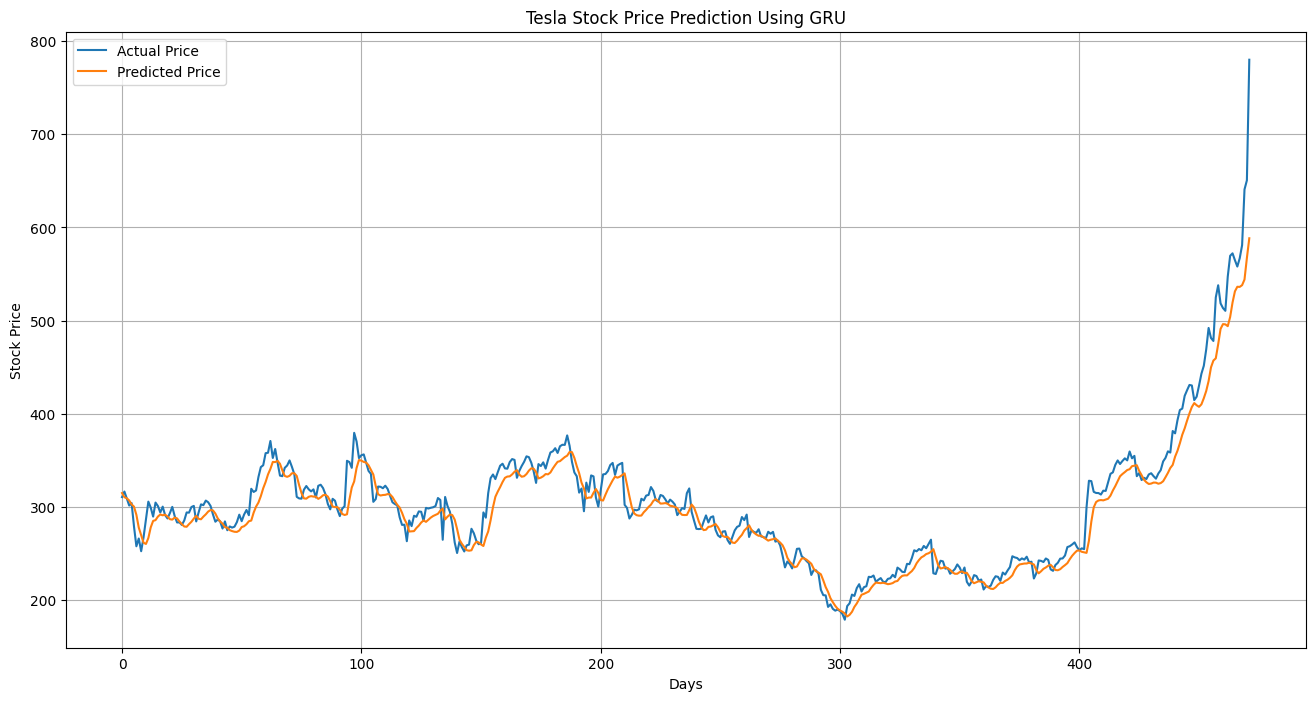

In [26]:
### Actual vs Predicted Graph

import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))

plt.plot(
y_actual,
label="Actual Price"
)

plt.plot(
gru_pred,
label="Predicted Price"
)

plt.title(
"Tesla Stock Price Prediction Using GRU"
)

plt.xlabel("Days")
plt.ylabel("Stock Price")

plt.legend()
plt.grid(True)

plt.show()


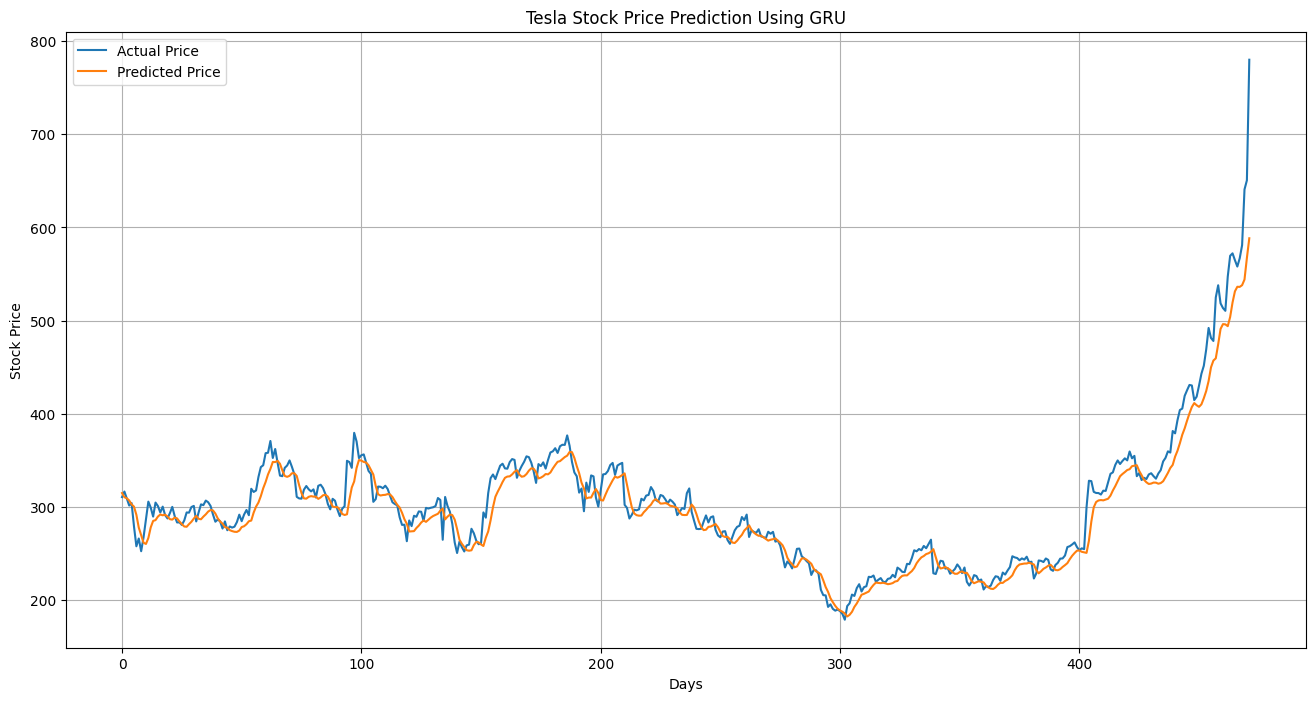

In [27]:
plt.figure(figsize=(16,8))

plt.plot(y_actual,label="Actual Price")
plt.plot(gru_pred,label="Predicted Price")

plt.title("Tesla Stock Price Prediction Using GRU")
plt.xlabel("Days")
plt.ylabel("Stock Price")

plt.legend()
plt.grid(True)

plt.savefig(
"Actual_vs_Predicted_GRU.png",
dpi=300,
bbox_inches="tight"
)

plt.show()


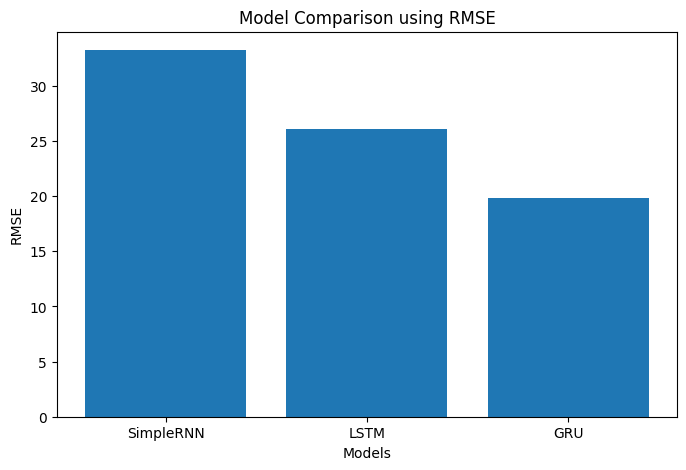

In [29]:
### Model Comparison Chart

import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
"Model": ["SimpleRNN", "LSTM", "GRU"],
"RMSE": [33.244189, 26.119912, 19.832115]
})

plt.figure(figsize=(8,5))

plt.bar(
comparison["Model"],
comparison["RMSE"]
)

plt.title("Model Comparison using RMSE")
plt.xlabel("Models")
plt.ylabel("RMSE")

plt.savefig(
"Model_Comparison_RMSE.png",
dpi=300,
bbox_inches="tight"
)

plt.show()


In [ ]:
### 1-Day Future Prediction

last_60_days = scaled_data[-60:]

X_future = np.array([last_60_days])

prediction_1_day = gru_model.predict(X_future)

prediction_1_day = scaler.inverse_transform(prediction_1_day)

print("Tomorrow Predicted Price:")
print(prediction_1_day[0][0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Tomorrow Predicted Price:
641.54047


In [ ]:
### 5-Day Future Prediction

future_input = scaled_data[-60:].copy()

future_predictions = []

for i in range(5):

    pred = gru_model.predict(
        future_input.reshape(1,60,1),
        verbose=0
    )

    future_predictions.append(pred[0][0])

    future_input = np.append(
        future_input[1:],
        pred
    )

future_predictions = scaler.inverse_transform(
np.array(future_predictions).reshape(-1,1)
)

print("Next 5 Day Predictions:")
print(future_predictions)


Next 5 Day Predictions:
[[641.54047]
 [638.4394 ]
 [625.6368 ]
 [612.4471 ]
 [600.2361 ]]


In [ ]:
### 10-Day Future Prediction

future_input = scaled_data[-60:].copy()

future_predictions_10 = []

for i in range(10):

    pred = gru_model.predict(
        future_input.reshape(1,60,1),
        verbose=0
    )

    future_predictions_10.append(pred[0][0])

    future_input = np.append(
        future_input[1:],
        pred
    )

future_predictions_10 = scaler.inverse_transform(
np.array(future_predictions_10).reshape(-1,1)
)

print("Next 10 Day Predictions:")
print(future_predictions_10)


Next 10 Day Predictions:
[[641.54047]
 [638.4394 ]
 [625.6368 ]
 [612.4471 ]
 [600.2361 ]
 [588.8631 ]
 [578.10394]
 [567.8328 ]
 [557.9867 ]
 [548.5288 ]]


In [ ]:
### Save Final GRU Model

import os

os.makedirs("../models", exist_ok=True)

gru_model.save("../models/final_gru_model.keras")


In [ ]:
import sys

print(sys.executable)


c:\Users\arjya\AppData\Local\Programs\Python\Python39\python.exe
